# INFO-6151 Data Visualization for Machine Learning
## Capstone Project | Objective: To create a logistic regression model to predict a video game's success.

**Name:** Olivia, Juno, Jadd
---

In [1]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

c:\Users\jaddm\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Our source is a dataset of steam games**<br>
Link - https://www.kaggle.com/datasets/artermiloff/steam-games-dataset<br>
Sample Below.

In [2]:
# Set the path to the file you'd like to load
file_path = "games_march2025_cleaned.csv" # This has unique rows

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "artermiloff/steam-games-dataset",
  file_path,
)
# Temporary need to see all feature details for dev purposes.
with pd.option_context('display.max_columns', None):
    print("First 5 records:", df.head())

First 5 records:     appid                             name release_date  required_age  price  \
0     730                 Counter-Strike 2   2012-08-21             0   0.00   
1  578080              PUBG: BATTLEGROUNDS   2017-12-21             0   0.00   
2     570                           Dota 2   2013-07-09             0   0.00   
3  271590        Grand Theft Auto V Legacy   2015-04-13            17   0.00   
4  359550  Tom Clancy's Rainbow Six® Siege   2015-12-01            17   3.99   

   dlc_count                               detailed_description  \
0          1  For over two decades, Counter-Strike has offer...   
1          0  LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...   
2          2  The most-played game on Steam. Every day, mill...   
3          0  When a young street hustler, a retired bank ro...   
4          9  Edition Comparison Ultimate Edition The Tom Cl...   

                                      about_the_game  \
0  For over two decades, Counter-Strike has

## Preprocessing 1/7
- We will drop some features that are irrelevant to our analysis.
- `score_rank` is null for the whole dataset so we will drop it
- Drop `notes`, `metacritic_url`, `support_url`, `support_email`, `website`, `reviews`, `short_description`, `detailed_description`, `about_the_game`. These are sentences about the game (If this class was NLP, we would use it but...)



Drop the heavy text/media columns, convert release_date to a real date, fills numeric missing values, keep platform flags clean, and add visualization-friendly columns like:
release_year, release_month
is_free
total_review_votes, review_balance
owners_min, owners_max, owners_midpoint
genres_count, developers_count, publishers_count, categories_count, supported_languages_count
main_genre, main_developer
tag_count

In [3]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd

COLS_TO_DROP = [
    "appid",
    "score_rank",
    "notes",
    "metacritic_url",
    "support_url",
    "support_email",
    "website",
    "reviews",
    "short_description",
    "detailed_description",
    "about_the_game",
    "header_image",
    "screenshots",
    "movies",
    "packages",
]

LIST_COLUMNS = [
    "supported_languages",
    "full_audio_languages",
    "developers",
    "publishers",
    "categories",
    "genres",
]


def parse_literal_list(value):
    if pd.isna(value) or value == "":
        return []
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return parsed
    except (ValueError, SyntaxError):
        pass
    return []


def owner_bounds(value):
    if pd.isna(value) or value == "":
        return pd.Series([np.nan, np.nan, np.nan])

    cleaned = str(value).replace(",", "")
    parts = [part.strip() for part in cleaned.split("-")]
    if len(parts) != 2:
        return pd.Series([np.nan, np.nan, np.nan])

    low = pd.to_numeric(parts[0], errors="coerce")
    high = pd.to_numeric(parts[1], errors="coerce")
    midpoint = np.nan if pd.isna(low) or pd.isna(high) else (low + high) / 2
    return pd.Series([low, high, midpoint])


def tag_count(value):
    if pd.isna(value) or value == "":
        return 0
    try:
        parsed = ast.literal_eval(value)
        return len(parsed) if isinstance(parsed, dict) else 0
    except (ValueError, SyntaxError):
        return 0


def preprocess_games(df):

    df = df.drop(columns=COLS_TO_DROP, errors="ignore").copy()

    df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
    df["release_year"] = df["release_date"].dt.year
    df["release_month"] = df["release_date"].dt.month

    bool_columns = ["windows", "mac", "linux"]
    for col in bool_columns:
        df[col] = df[col].fillna(False).astype(bool)

    numeric_columns = [
        "required_age",
        "price",
        "dlc_count",
        "metacritic_score",
        "achievements",
        "recommendations",
        "user_score",
        "positive",
        "negative",
        "average_playtime_forever",
        "average_playtime_2weeks",
        "median_playtime_forever",
        "median_playtime_2weeks",
        "discount",
        "peak_ccu",
        "pct_pos_total",
        "num_reviews_total",
        "pct_pos_recent",
        "num_reviews_recent",
    ]

    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    zero_fill_columns = [
        "required_age",
        "price",
        "dlc_count",
        "metacritic_score",
        "achievements",
        "recommendations",
        "user_score",
        "positive",
        "negative",
        "average_playtime_forever",
        "average_playtime_2weeks",
        "median_playtime_forever",
        "median_playtime_2weeks",
        "discount",
        "peak_ccu",
        "pct_pos_total",
        "num_reviews_total",
        "pct_pos_recent",
        "num_reviews_recent",
    ]

    df[zero_fill_columns] = df[zero_fill_columns].fillna(0)
    df["name"] = df["name"].fillna("Unknown")

    df["is_free"] = df["price"].eq(0).astype(int)
    df["total_review_votes"] = df["positive"] + df["negative"]
    df["review_balance"] = df["positive"] - df["negative"]

    df[["owners_min", "owners_max", "owners_midpoint"]] = df["estimated_owners"].apply(owner_bounds)

    for col in LIST_COLUMNS:
        parsed_col = f"{col}_parsed"
        count_col = f"{col}_count"
        df[parsed_col] = df[col].apply(parse_literal_list)
        df[count_col] = df[parsed_col].apply(len)
        df[col] = df[parsed_col].apply(lambda items: ", ".join(items))
        df = df.drop(columns=[parsed_col])

    df["main_genre"] = df["genres"].apply(
        lambda value: value.split(", ")[0] if isinstance(value, str) and value else "Unknown"
    )
    df["main_developer"] = df["developers"].apply(
        lambda value: value.split(", ")[0] if isinstance(value, str) and value else "Unknown"
    )
    df["tag_count"] = df["tags"].apply(tag_count)

    ordered_columns = [
        "name",
        "release_date",
        "release_year",
        "release_month",
        "main_genre",
        "genres",
        "genres_count",
        "main_developer",
        "developers",
        "developers_count",
        "publishers",
        "publishers_count",
        "categories",
        "categories_count",
        "supported_languages",
        "supported_languages_count",
        "full_audio_languages",
        "full_audio_languages_count",
        "price",
        "is_free",
        "discount",
        "required_age",
        "dlc_count",
        "windows",
        "mac",
        "linux",
        "metacritic_score",
        "user_score",
        "recommendations",
        "achievements",
        "positive",
        "negative",
        "total_review_votes",
        "review_balance",
        "pct_pos_total",
        "num_reviews_total",
        "pct_pos_recent",
        "num_reviews_recent",
        "estimated_owners",
        "owners_min",
        "owners_max",
        "owners_midpoint",
        "average_playtime_forever",
        "average_playtime_2weeks",
        "median_playtime_forever",
        "median_playtime_2weeks",
        "peak_ccu",
        "tag_count",
        "tags",
    ]

    df = df[[col for col in ordered_columns if col in df.columns]]
    df = df.sort_values(["release_year", "name"], ascending=[False, True]).reset_index(drop=True)

    print(f"Final shape: {df.shape}")
    print("\nMissing values after preprocessing:")
    print(df.isna().sum())
    print("\nPreview:")
    print(df.head())

    return df


df_clean = preprocess_games(df)


Final shape: (89618, 49)

Missing values after preprocessing:
name                          0
release_date                  0
release_year                  0
release_month                 0
main_genre                    0
genres                        0
genres_count                  0
main_developer                0
developers                    0
developers_count              0
publishers                    0
publishers_count              0
categories                    0
categories_count              0
supported_languages           0
supported_languages_count     0
full_audio_languages          0
full_audio_languages_count    0
price                         0
is_free                       0
discount                      0
required_age                  0
dlc_count                     0
windows                       0
mac                           0
linux                         0
metacritic_score              0
user_score                    0
recommendations               0
achievemen

## Preprocessing 2/7 - CREATE TARGET CRITERIA
If 80% of reviews are positive, the game is labelled as a success.<br>
From stats below, we can see that only 75% of games have 70+ reviews and 50% only have 13+.<br>
Therefore minimum review amount is 50 so 40% of the count, which is 36,000, is used for the model.

In [4]:
from pandas import DataFrame
MIN_REVIEWS = 15

df_ml = df_clean.copy()

def success_criteria(pos_num, neg_num):
    total = pos_num + neg_num
    if total < MIN_REVIEWS:
        return False

    ratio = pos_num / total
    if ratio < 0.65:
        return False
    return True

df_ml['is_success'] = df_ml.apply(lambda row: success_criteria(row['positive'], row['negative']), axis=1)
                       
temp_df = DataFrame()
temp_df['total_reviews'] = df_ml['positive'] + df_ml['negative']
with pd.option_context('display.float_format', '{:.0f}'.format):
    print(temp_df['total_reviews'].describe())

count     89618
mean       1480
std       36991
min           0
25%           2
50%          13
75%          78
max     8615921
Name: total_reviews, dtype: float64


## PREPROCESS 3/7 - DROP MORE UNSUITABLE COLUMNS
We can further remove columns like names, lists, redundant columns. These unneeded columns are just noise for machine learning.

In [5]:
print(f"Number of Columns before dropping {df_ml.shape[1]}")
COLS_TO_DROP_ML = [
    "name",
    "release_date",
    "genres",
    "genres_count",
    "developers",
    "developers_count",
    "publishers",
    "publishers_count",
    "categories",
    "categories_count",
    "supported_languages_count",
    "full_audio_languages",
    "full_audio_languages_count",
    "is_free",
    "windows",
    "positive",
    "negative",
    "estimated_owners",
    "owners_min",
    "owners_max",
    "median_playtime_forever",
    "median_playtime_2weeks",
    "tag_count",
    "tags",
    "review_balance",
    "pct_pos_total"
]
df_ml.drop(columns=COLS_TO_DROP_ML, inplace=True)
print(f"Number of Columns After dropping {df_ml.shape[1]}")

Number of Columns before dropping 50
Number of Columns After dropping 24


# PREPROCESS 4/7 - ENCODE CATEGORICAL COLUMNS
As seen in the sample, the are columns holding categorical data like genre and developers. There are also columns with high cardinality. We will replace them with numbers.

In [6]:
bins = [1999, 2009, 2019, 2029]
labels = ['2000-2009','2010-2019','2020-2029']
df_ml['decade'] = pd.cut(df_ml['release_year'], bins=bins, labels=labels)
df_ml = pd.get_dummies(df_ml, columns=['decade'], drop_first=True)
df_ml.drop(columns="release_year", inplace=True)

def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_ml['Season'] = df_ml['release_month'].apply(month_to_season)
print(f"Example, Before Encode: Season - {df_ml['Season'][0]}")
df_ml = df_ml.drop(columns="release_month")
df_ml = pd.get_dummies(df_ml, columns=['Season'], drop_first=True)
print(f"Example, After Encode: Spring - {df_ml['Season_Spring'][0]}, Summer - {df_ml['Season_Summer'][0]}, Winter {df_ml['Season_Winter'][0]}")

top_genres = df_ml['main_genre'].value_counts().nlargest(8).index
top_devs = df_ml['main_developer'].value_counts().nlargest(10).index

df_ml['main_genre'] = df_ml['main_genre'].where(df_ml['main_genre'].isin(top_genres), 'Other')
df_ml['main_developer'] = df_ml['main_developer'].where(df_ml['main_developer'].isin(top_devs), 'Other')

df_ml = pd.get_dummies(df_ml, columns=['main_genre'], drop_first=True)
df_ml = pd.get_dummies(df_ml, columns=['main_developer'], drop_first=True)

df_ml['main_language'] = df_ml['supported_languages'].apply(
        lambda value: value.split(", ")[0] if isinstance(value, str) and value else "Unknown"
    )
df_ml = df_ml.drop(columns="supported_languages")

top_langs = df_ml['main_language'].value_counts().nlargest(8).index
df_ml['main_language'] = df_ml['main_language'].where(df_ml['main_language'].isin(top_langs), 'Other')
df_ml = pd.get_dummies(df_ml, columns=['main_language'], drop_first=True)

print("Encoding of Appropriate Columns Finished")

Example, Before Encode: Season - Winter
Example, After Encode: Spring - False, Summer - False, Winter True
Encoding of Appropriate Columns Finished


## PREPROCESS 5/7 - REMOVE OUTLIERS
Uber-popular games have sky-rocketing interactions while underground games get very few. We will minimize these extremes because an extreme<br>
value may have too much influence and confuse the model.<br>
For example, lets say price hovers around $60 a game and the high-end is $80. A few game can cost $1000 and negatively influence the model. So we try to<br>
put it at normal range at like $100, so it still classifies as high-end but doesn't push the model extremely.

In [7]:
numeric_cols = df_ml.select_dtypes(include='number', exclude='bool').columns

for col in numeric_cols:
    Q1 = df_ml[col].quantile(0.25)
    Q3 = df_ml[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_ml = df_ml[
        (df_ml[col] >= lower) &
        (df_ml[col] <= upper)
    ]

print("Outliers minimized")

Outliers minimized


## PREPROCESS 6/7 - SCALE NUMBERS
A review score can be 0 - 100 but age scale is much different. When a model reads these, they'll get confused so we must scale the numbers so they are proportionate.

In [8]:
from sklearn.preprocessing import StandardScaler

print("Before Scaling")
print(df_ml['price'].describe())

scaler = StandardScaler()
numeric_cols = df_ml.select_dtypes(include='number', exclude='bool').columns
df_ml[numeric_cols] = scaler.fit_transform(df_ml[numeric_cols])

bool_cols = df_ml.select_dtypes(include='bool', exclude='number').columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

print("After Scaling")
print(df_ml['price'].describe())

Before Scaling
count    34526.000000
mean         5.378857
std          4.534014
min          0.000000
25%          1.990000
50%          4.990000
75%          7.990000
max         22.990000
Name: price, dtype: float64
After Scaling
count    3.452600e+04
mean    -4.115986e-18
std      1.000014e+00
min     -1.186352e+00
25%     -7.474405e-01
50%     -8.576554e-02
75%      5.759094e-01
max      3.884284e+00
Name: price, dtype: float64


## PREPROCESS 7/7 - REMOVE NON-INDEPENDENT COLUMNS
Sometimes, columns can correlate too much, for example, if it sunny it's probably hot and other way around. You only need one columns tell that story.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["feature"] = df_ml.columns
vif["VIF"] = [variance_inflation_factor(df_ml.values, i) for i in range(df_ml.shape[1])]
print(vif)

independent = vif[vif['VIF'] <= 5]
independent_cols = independent['feature'].tolist()
exclusive = list(set(independent_cols) ^ set(df_ml.columns.tolist()))

print(f"Number of Columns BEFORE dropping: {df_ml.shape[1]}")
for col in exclusive:
    df_ml.drop(col, axis=1, inplace=True)

print(f"Number of Columns AFTER dropping: {df_ml.shape[1]}")

C:\Users\jaddm\AppData\Roaming\Python\Python310\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


                                    feature         VIF
0                                     price    1.041472
1                                  discount         NaN
2                              required_age         NaN
3                                 dlc_count         NaN
4                                       mac    1.575130
5                                     linux    1.505613
6                          metacritic_score         NaN
7                                user_score         NaN
8                           recommendations         NaN
9                              achievements    1.079690
10                       total_review_votes    3.599445
11                        num_reviews_total    3.005515
12                           pct_pos_recent         NaN
13                       num_reviews_recent         NaN
14                          owners_midpoint         NaN
15                 average_playtime_forever         NaN
16                  average_playtime_2weeks     

## Visualizations

In [10]:
# Start from cleaned dataframe
df_pca = df_clean.copy()

# Multi-hot encode genres
genres_dummies = df_pca["genres"].str.get_dummies(sep=", ")
df_pca = pd.concat([df_pca, genres_dummies], axis=1)

# Drop raw text/date columns that should not go into PCA
cols_to_remove_for_pca = [
    "name",
    "release_date",
    "genres",
    "main_genre",
    "developers",
    "main_developer",
    "publishers",
    "categories",
    "supported_languages",
    "full_audio_languages",
    "estimated_owners",
    "tags",
]

df_pca = df_pca.drop(columns=cols_to_remove_for_pca, errors="ignore")

# Keep only numeric + boolean columns
df_pca = df_pca.select_dtypes(include=["number", "bool"])

print(df_pca.shape)
print(df_pca.head())

(89618, 70)
   release_year  release_month  genres_count  developers_count  \
0          2025              2             4                 1   
1          2025              2             4                 1   
2          2025              2             3                 1   
3          2025              1             2                 1   
4          2025              3             3                 1   

   publishers_count  categories_count  supported_languages_count  \
0                 1                 1                          1   
1                 1                 2                          1   
2                 1                 3                          3   
3                 1                 4                          1   
4                 1                 2                         25   

   full_audio_languages_count  price  is_free  ...  Short  Simulation  \
0                           0   0.00        1  ...      0           0   
1                           1   0.99

In [11]:
df_no_outliers = df_pca.copy()

outlier_cols = [
    "price",
    "positive",
    "negative",
    "recommendations",
    "average_playtime_forever",
    "peak_ccu",
    "owners_midpoint",
]

for col in outlier_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower) & (df_no_outliers[col] <= upper)
    ]

print(df_pca.shape)
print(df_no_outliers.shape)


(89618, 70)
(44259, 70)


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original PCA input shape:", df_pca.shape)
print("Reduced shape:", X_pca.shape)

Original PCA input shape: (89618, 70)
Reduced shape: (89618, 47)


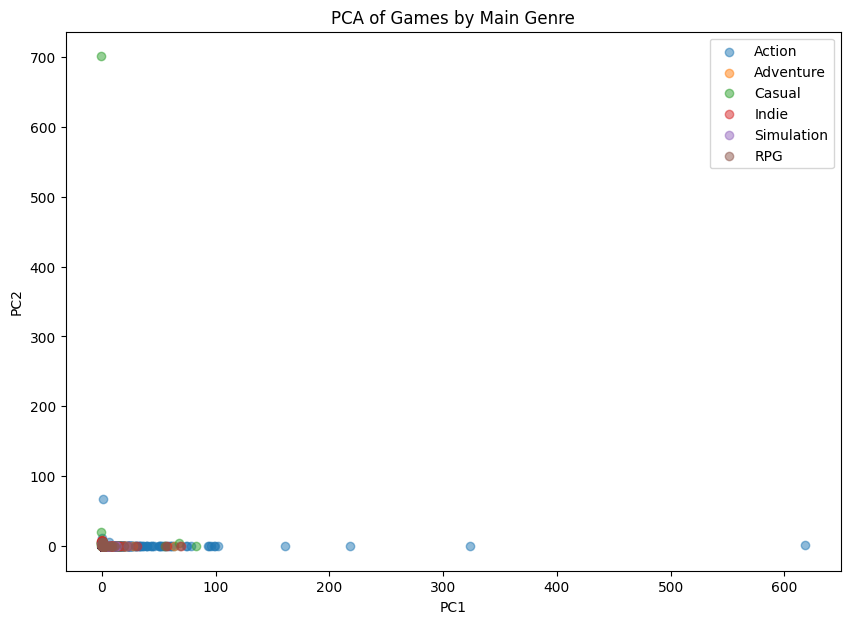

In [13]:
import matplotlib.pyplot as plt

pca_plot_df = df_clean[["name", "main_genre"]].copy()
pca_plot_df["PC1"] = X_pca[:, 0]
pca_plot_df["PC2"] = X_pca[:, 1]

top_genres = pca_plot_df["main_genre"].value_counts().head(6).index
plot_df = pca_plot_df[pca_plot_df["main_genre"].isin(top_genres)]

plt.figure(figsize=(10, 7))

for genre in top_genres:
    subset = plot_df[plot_df["main_genre"] == genre]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.5, label=genre)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Games by Main Genre")
plt.legend()
plt.show()

We used PCA to reduce many features into two main components so that we can visualize the data in a simpler way.

In this plot, each point represents a game, and colors represent different genres.

We can see that most genres are mixed together, which means there is no clear separation between them based on the selected features.

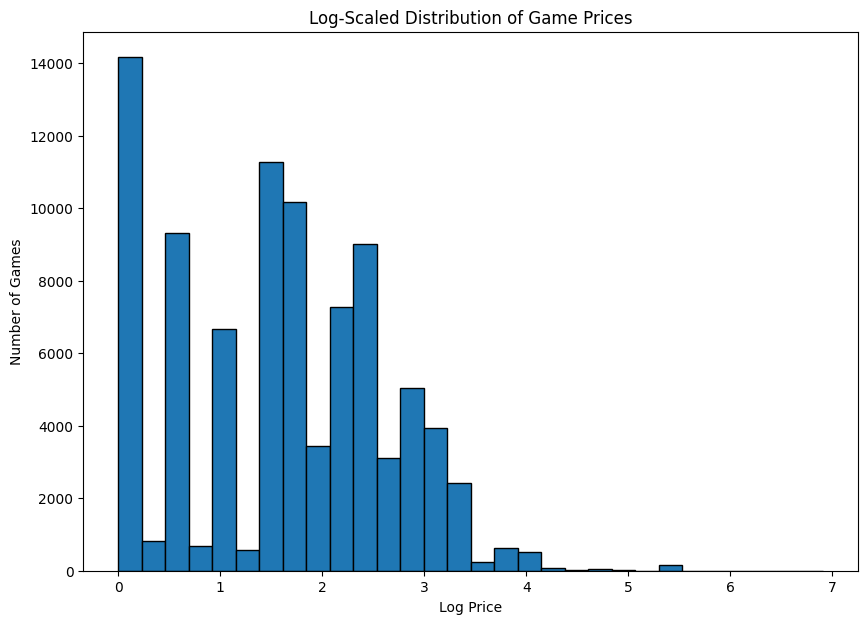

In [14]:
#To show how game prices are spread.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.hist(np.log1p(df_clean["price"]), bins=30, edgecolor='black')
plt.title('Log-Scaled Distribution of Game Prices')
plt.xlabel('Log Price')
plt.ylabel('Number of Games')
plt.show()

We used a histogram to understand how game prices are distributed.

The X-axis shows game prices (log-scaled), and the Y-axis shows the number of games in each price range.

We can see that most games are concentrated in the lower price range, which means most games are free or low-cost, while only a few games are expensive.

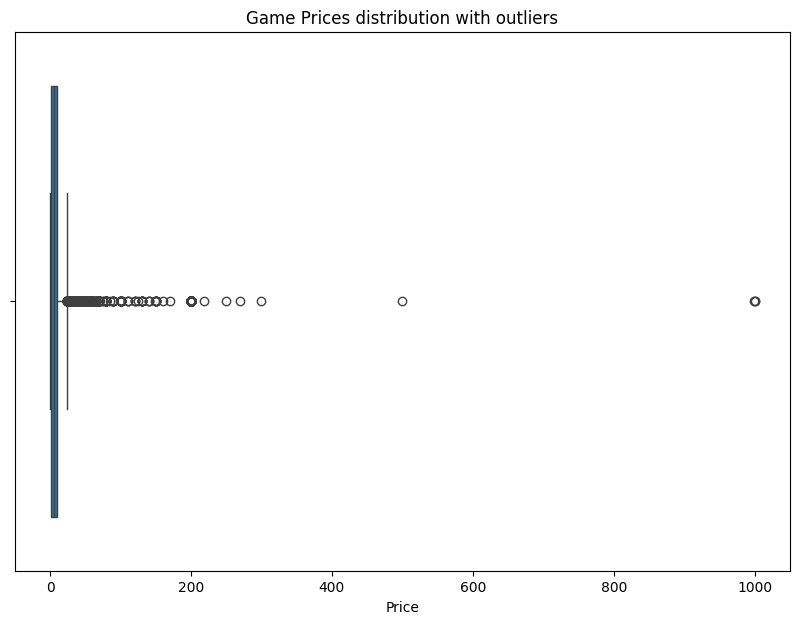

In [15]:
#showing outliers, expensive games clearly.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.boxplot(x=df_clean["price"])
plt.title('Game Prices distribution with outliers')
plt.xlabel('Price')
plt.show()


We used a boxplot to identify outliers in game prices.

The box represents the range where most game prices fall, and the points outside the box represent extreme values.

We can see that most games are low-priced, but there are a few very expensive games that act as outliers.

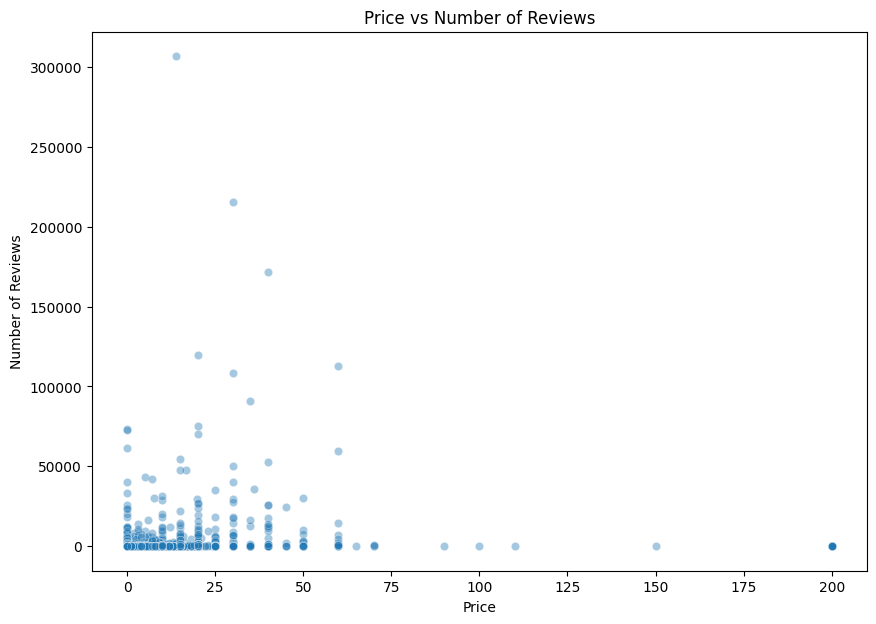

In [16]:
#shows the relationship between game price and the number of reviews.
sample_df = df_clean.sample(5000, random_state = 42)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="price",
    y="num_reviews_total",
    data=sample_df,
    alpha = 0.4
)

plt.title("Price vs Number of Reviews")
plt.xlabel("Price")
plt.ylabel("Number of Reviews")

plt.show()

We used a scatter plot to analyze the relationship between game price and the number of reviews.

We chose these variables to understand whether more expensive games are more popular.

Each point represents a game, and we can see that most games have low prices and low review counts. There is no strong correlation between price and popularity.

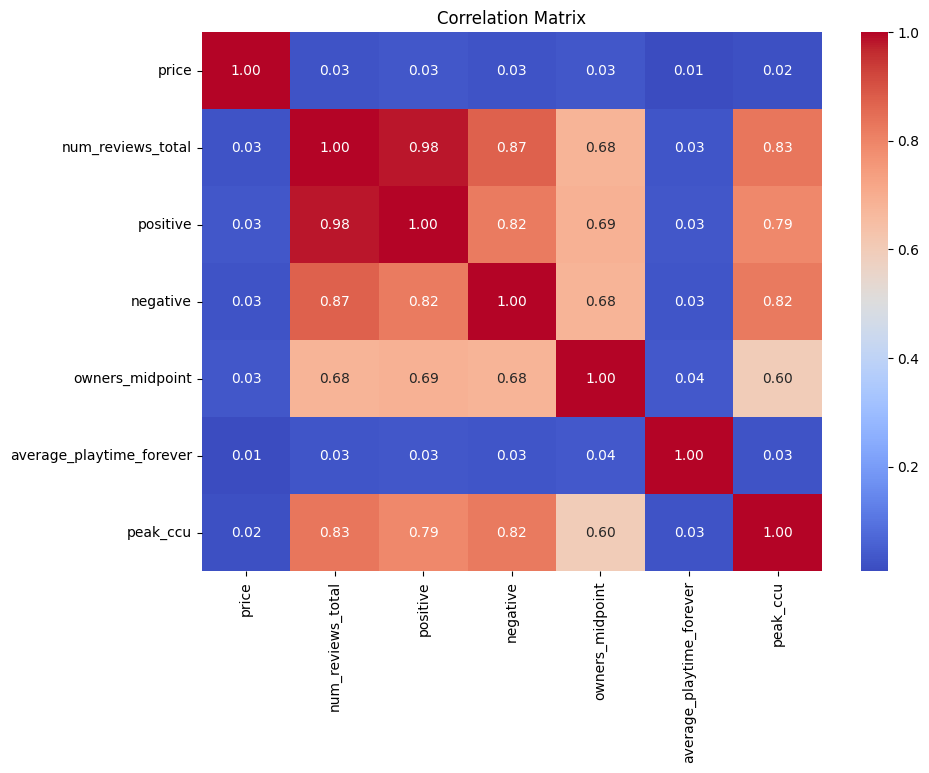

In [17]:
#correlation between vars
import seaborn as sns
import matplotlib.pyplot as plt

#selected some important columns
selected_cols = [
    "price",
    "num_reviews_total",
    "positive",
    "negative",
    "owners_midpoint",
    "average_playtime_forever",
    "peak_ccu"
]

small_df = df_clean[selected_cols]

plt.figure(figsize=(10, 7))
sns.heatmap(small_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

We used a heatmap to understand the relationships between key variables in the dataset.

We selected these variables because they represent price, popularity, and player activity.

The colors indicate the strength of correlation, where darker red shows a strong relationship and blue shows a weak relationship.

We can see strong correlations between review-related features and player activity, such as number of reviews, positive/negative feedback, and peak player count.

However, price shows very weak correlation with other variables, indicating that price does not significantly affect game popularity.

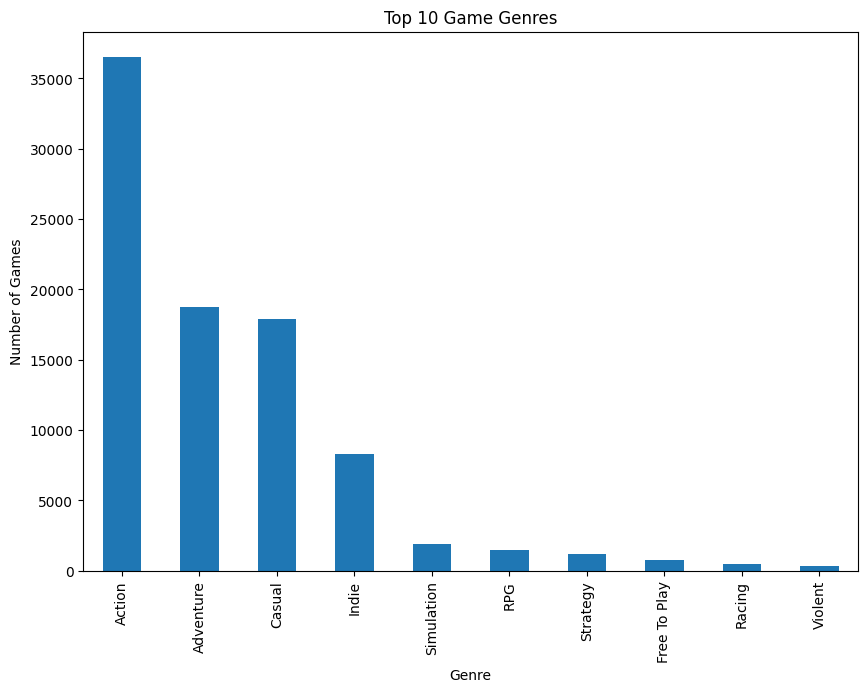

In [18]:
#showing Top generes
top_genres = df_clean["main_genre"].value_counts().head(10)

plt.figure(figsize=(10, 7))
top_genres.plot(kind="bar")

plt.title("Top 10 Game Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Games")

plt.show()

We used the above chart to understand the distribution of game genres.

The X-axis shows different genres, and the Y-axis shows the number of games in each genre.

We can see that action games are the most common, followed by adventure and casual.

This indicates that these genres are more popular among developers and are more frequently produced in the dataset.

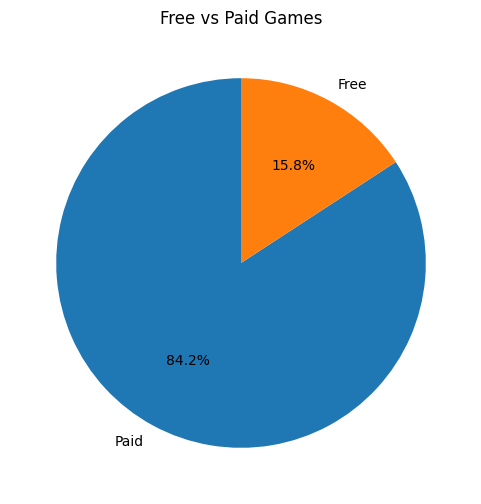

In [19]:
free_paid = df_clean["is_free"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(free_paid, labels=["Paid", "Free"], autopct="%1.1f%%", startangle=90)

plt.title("Free vs Paid Games")
plt.show()

This pie chart shows the proportion of free and paid games in the dataset. Most games are paid, while a smaller percentage are free-to-play. This indicates that paid games dominate the dataset.

## MODELLING

**TRAIN MODEL - FIT LOGISTIC REGRESSION**<br>
We are using a logistic regression, which is used for binary(two) classification. Our target value is "Success."

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

TARGET_COL = "is_success"
SEED = 77

y_col_index = df_ml.columns.get_loc(TARGET_COL)
X = df_ml.drop(columns=TARGET_COL).values
y = df_ml.iloc[:, y_col_index].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

model = LogisticRegression(max_iter=500)
_ = model.fit(X_train, y_train)

In [21]:
# To check the imbalance of dataset, its already quite imbalanced
# unique, counts = np.unique(y, return_counts=True)
# percentages = counts / counts.sum()
# print(dict(zip(unique, counts)))
# print(dict(zip(unique, percentages)))

**EVALUATE MODEL**<br>
The model is succesfully able to predict a game's success based on seperate features at an accuracy of **88%!**

MODEL ACCURACY IS:  0.8876339415001449
MODEL PRECISION IS: 0.7049659201557936
MODEL RECALL IS:    0.6048454469507101
MODEL F1 IS:        0.6510791366906474


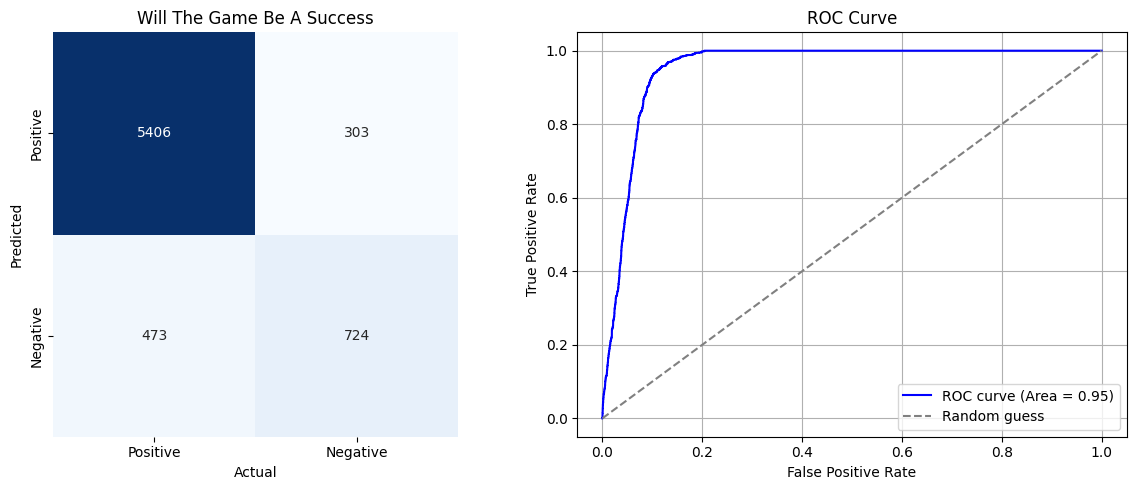

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, \
    recall_score, f1_score, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"MODEL ACCURACY IS:  {accuracy}")
print(f"MODEL PRECISION IS: {precision}")
print(f"MODEL RECALL IS:    {recall}")
print(f"MODEL F1 IS:        {f1}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
dis = sns.heatmap(
    cm,
    ax=axes[0],
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    square=True,
    xticklabels=["Positive", "Negative"],
    yticklabels=["Positive", "Negative"]
)
axes[0].set_ylabel("Predicted")
axes[0].set_xlabel("Actual")
axes[0].set_title("Will The Game Be A Success")

y_prob = model.predict_proba(X_test)[:, 1]
false_rate, true_rate, _ = roc_curve(y_test, y_prob)
area = roc_auc_score(y_test, y_prob)

axes[1].plot(false_rate, true_rate, color='blue', label=f'ROC curve (Area = {area:.2f})')
axes[1].plot([0,1], [0,1], color='gray', linestyle='--', label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## BUILDING OF INTERACTIVE VISUALIZATIONS - DASH, SHAP...<br>
To view on a browser go to this: http://127.0.0.1:8050/

In [23]:
import shap
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
from ydata_profiling import ProfileReport

In [24]:
# THIS FOR OPENING THE INTERACTIVE VISUAL IN COLAB

# !pip install pyngrok
# from pyngrok import ngrok

# ngrok.set_auth_token("3BUSOIdBGcEqQMKvXXNqUSjNrpc_Wq78AHuK6hdV9144iXFa")
# public_url = ngrok.connect(8050)
# print(public_url)

In [25]:
profile = ProfileReport(df_clean, minimal=True)
profile.to_file("profile_report.html")

explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test)

importance = np.abs(shap_values).mean(axis=0)

feature_importance = sorted(
    zip(
        df_ml.columns,
        importance,
        ["positive" if val > 0 else "negative" for val in shap_values.mean(axis=0)]),
    key=lambda x: x[1],
    reverse=True
)

num_cols_viz  = [
    "release_date",
    "release_year",
    "release_month",
    "genres_count",
    "developers_count",
    "publishers_count",
    "categories_count",
    "supported_languages_count",
    "full_audio_languages_count",
    "price",
    "discount",
    "required_age",
    "dlc_count",
    "metacritic_score",
    "user_score",
    "recommendations",
    "achievements",
    "positive",
    "negative",
    "total_review_votes",
    "review_balance",
    "pct_pos_total",
    "num_reviews_total",
    "pct_pos_recent",
    "num_reviews_recent",
    "owners_min",
    "owners_max",
    "owners_midpoint",
    "average_playtime_forever",
    "average_playtime_2weeks",
    "median_playtime_forever",
    "median_playtime_2weeks",
    "peak_ccu",
    "tag_count"
]

cat_cols_viz = [
    "main_genre",
    "main_developer",
    "is_free",
]

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 57.07it/s]


In [28]:
external_stylesheets = [
    "https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css"
]

app = dash.Dash(__name__, external_stylesheets=external_stylesheets)

app.layout = html.Div(
    children=[
        html.Div(
            children=[
                html.Div(
                    children=[
                        html.Div(
                            children=[
                                html.I(
                                    className="fa-solid fa-chart-column",
                                    style={
                                        "paddingRight": "10px"
                                    }
                                ),
                                html.Div(
                                    "An Examination of Game Success on Steam"
                                )
                            ],
                            style={
                                "display": "flex",
                                "font-size": "34px"
                            }                                                          
                        ),
                        html.P(
                            children=[
                                "This report analyzes the product prices of Steam, the world go-to market for online-accessed games. " \
                                "We will use artificial intelligence methods to identify characteristics that, use humans, would ",
                                html.I(
                                    "not otherwise see."
                                )
                            ],
                            style={
                                "lineHeight": "2",
                                "font-size": "22px"
                            }
                        ),
                        html.Div(
                            children=[
                                html.Div(
                                    children=[
                                        html.I(
                                            className="fa-solid fa-circle-user",
                                            style={
                                                "paddingRight": "10px"
                                            }
                                        ),
                                        "Written by: Olivia K., Juno J., Jadd A." 
                                    ],
                                    style={
                                        "border": "2px solid black",
                                        "borderRadius": "10px",
                                        "padding": "5px"
                                    }                                                                 
                                ),
                                html.Div(
                                    children=[
                                        html.I(
                                            className="fa-regular fa-calendar",
                                            style={
                                                "paddingRight": "10px"
                                            }
                                        ),
                                        "Updated: April 1, 2026" 
                                    ],
                                    style={
                                        "border": "2px solid black",
                                        "borderRadius": "10px",
                                        "padding": "5px"
                                    }                                                                                        
                                ),
                                html.Div(
                                    children=[
                                        html.I(
                                            className="fa-solid fa-database",
                                            style={
                                                "paddingRight": "10px"
                                            }
                                        ),
                                        "Source: " ,
                                        html.A(
                                            "Kaggle Steam Dataset",
                                            href="https://www.kaggle.com/datasets/artermiloff/steam-games-dataset",
                                            target="_blank",
                                            style={
                                                "textDecoration": "none"
                                            }
                                        ),
                                    ],  
                                    style={
                                        "border": "2px solid black",
                                        "borderRadius": "10px",
                                        "padding": "5px"
                                    }                                                                             
                                )
                            ],
                            style={
                                "display": "flex",
                                "gap": "8px",
                                "font-size": "14px"
                            }   
                        ),
                    ],
                    style={
                        "flex": 5
                    }
                ),
                html.Div(
                    children=[
                        html.Div(
                            children=[
                                html.A(
                                    "Fanshawe College",
                                    href="https://www.fanshawec.ca/programs/aim2-artificial-intelligence-and-machine-learning-co-op/next#",
                                    target="_blank",
                                    style={
                                        "textDecoration": "none"
                                    }
                                ),
                                html.I(
                                    className="fa-solid fa-school",
                                    style={
                                        "paddingLeft": "10px",
                                    }
                                )
                            ]                                                                        
                        ),
                        html.Div(
                            children=[
                                html.A(
                                    "Steam",
                                    href="https://store.steampowered.com",
                                    target="_blank",
                                    style={
                                        "textDecoration": "none"
                                    }
                                ),
                                html.I(
                                    className="fa-brands fa-steam",
                                    style={
                                        "paddingLeft": "10px",
                                    }
                                )
                            ],                                                          
                        )
                    ],
                    style={
                        "flex": "5",
                        "font-size": "35px",
                        "textAlign": "center",
                        "lineHeight": "2"
                    }
                ),
            ],
            style={
                "display": "flex",
                "paddingBottom": "35px",
                "fontFamily": "Inter, sans-serif"
            }
        ),
        html.Div(
            children=[
                html.Div(
                    children=[
                        html.H2("Most Decisive Features"),
                        dcc.Slider(id="feat_nums", min=1, max=20, value=10, step=1),
                        dcc.RadioItems(id="pol_show", options=['Positive', 'Both','Negative'], value ='Both', inline=True),
                        dcc.Graph(id="shap_bar")
                    ],
                    style={
                        "flex": 5,
                        "border": "2px solid black",
                        "borderRadius": "10px",
                        "padding": "8px"
                    }
                ),
                html.Div(
                    children=[
                        html.H2("Compare Graph"),
                        html.Label("X-Axis"),
                        dcc.Dropdown(id='compare_feat', options=num_cols_viz, value='user_score'),
                        html.Label("Y-Axis"),
                        dcc.Dropdown(id='compare_feat2', options=num_cols_viz, value='price'),
                        dcc.Graph(id="compare_graph")
                    ],
                    style={
                        "flex": 5,
                        "border": "2px solid black",
                        "borderRadius": "10px",
                        "padding": "8px",
                    }
                )
            ],  
            style={
                "paddingTop": "15px",
                "paddingBottom": "15px",
                "display": "flex",
                "gap": "12px"
            }
        ),
        html.Div(
            children=[
                html.Div(
                    children=[
                        html.H2("Catgeory Chart"),
                        dcc.Dropdown(id='category', options=cat_cols_viz, value='main_genre'),
                        dcc.Graph(id="cat_graph")
                    ],
                    style={
                        "flex": 5,
                        "border": "2px solid black",
                        "borderRadius": "10px",
                        "padding": "8px",
                    }
                ),
                html.Div(
                    children=[
                        html.H2("Count Graph"),
                        dcc.Dropdown(id='feat', options=num_cols_viz, value ='metacritic_score'),
                        dcc.RadioItems(id="feat_view", options=['Histogram', "Box Plot"], value ='Histogram', inline=True),
                        dcc.Graph(id="count_graph")
                    ],
                    style={
                        "flex": 5,
                        "border": "2px solid black",
                        "borderRadius": "10px",
                        "padding": "8px",
                    }
                )

            ],  
            style={
                "paddingTop": "15px",
                "paddingBottom": "15px",
                "display": "flex",
                "gap": "12px"
            }
        ),
        html.Div(
            html.Iframe(
                srcDoc=profile.to_html(),
                style={
                    "width": "100%",
                    "height": "600px",
                    "border": "2px solid black",
                    "borderRadius": "10px",
                    "padding": "8px"
                }
            )
        ),
    ],
    style={
        "padding": "35px"
    }
)

@app.callback(
    Output("shap_bar", "figure"),
    Input("feat_nums", "value"),
    Input("pol_show", "value")
)
def update_shap_fig(feat_nums, pol_show):
    pol_show = pol_show.lower()
    top_features = [f[0] for f in feature_importance[:feat_nums] if f[2] == pol_show or pol_show == "both"]
    top_values = [f[1] for f in feature_importance[:feat_nums] if f[2] == pol_show or pol_show == "both"]
    top_polarities = [f[2] for f in feature_importance[:feat_nums] if f[2] == pol_show or pol_show == "both"]

    return px.bar(
        x=top_values[::-1],
        y=top_features[::-1],
        color=top_polarities[::-1],
        labels={
            "x": "Prediction Magnitude",
            "y": "Feature"
        },
    )

@app.callback(
    Output("compare_graph", "figure"),
    Input("compare_feat", "value"),
    Input("compare_feat2", "value")
)
def update_compare_graph(feat1, feat2):
    return px.scatter(
        df_clean,
        x=feat1,
        y=feat2
    )

@app.callback(
    Output("count_graph", "figure"),
    Input("feat", "value"),
    Input("feat_view", "value")
)
def update_count_graph(col, view):

    counts = df_clean[col].value_counts().reset_index()
    counts.columns = [col, 'count']

    if view.lower() == "box plot":
        return px.box(
            counts,
            x='count',
            log_x=True, 
            orientation='h'  
        )

    return px.histogram(
        counts,
        x=col,
        y='count',
        log_y=True
    )

@app.callback(
    Output("cat_graph", "figure"),
    Input("category", "value")
)
def update_category_graph(category):

    top_n = 8
    counts = df_clean[category].value_counts()
    top_counts = counts[:top_n]
    other_count = counts[top_n:].sum()
    top_counts['other'] = other_count 

    return px.pie(
        names=top_counts.index,
        values=top_counts.values
    )

if __name__ == '__main__':
    app.run(port=8050, debug=False)